In [1]:
# Cell 1: Imports
# pandas: our main tool for looking at tabular data
# datasets: Hugging Face library for loading our saved datasets
# matplotlib: for drawing charts

import pandas as pd
from datasets import load_from_disk
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [2]:
# Cell 2: Load the NER dataset
# load_from_disk reads the dataset we saved in Step 2
# We convert it to a pandas DataFrame because pandas is
# much easier to explore than raw Hugging Face dataset objects

ner_ds = load_from_disk('../data/raw/ner_resumes')
print("Splits in NER dataset:", ner_ds)
print()

# Most HuggingFace datasets have a 'train' split
# Let's convert it to a DataFrame
if 'train' in ner_ds:
    ner_df = ner_ds['train'].to_pandas()
else:
    # If there's only one split, take the first one
    split_name = list(ner_ds.keys())[0]
    ner_df = ner_ds[split_name].to_pandas()

print(f"Shape: {ner_df.shape[0]} rows × {ner_df.shape[1]} columns")
print()
print("Columns:", list(ner_df.columns))

Splits in NER dataset: DatasetDict({
    train: Dataset({
        features: ['pdf'],
        num_rows: 10064
    })
})

Shape: 10064 rows × 1 columns

Columns: ['pdf']


In [3]:
# Cell 3: Check for nulls and data types
# isnull().sum() counts missing values per column
# dtypes tells us what type each column is (string, int, etc.)

print("=== NULL COUNTS ===")
print(ner_df.isnull().sum())
print()
print("=== DATA TYPES ===")
print(ner_df.dtypes)
print()
print("=== FIRST 3 ROWS (display) ===")
ner_df.head(3)

=== NULL COUNTS ===
pdf    0
dtype: int64

=== DATA TYPES ===
pdf    object
dtype: object

=== FIRST 3 ROWS (display) ===


,pdf
0,"{'bytes': None, 'path': 'zip://ResumesJsonAnno..."
1,"{'bytes': None, 'path': 'zip://ResumesJsonAnno..."
2,"{'bytes': None, 'path': 'zip://ResumesJsonAnno..."


In [4]:
# Cell 4: Look at one actual record
# This is the most important EDA step —
# reading real data tells you more than any statistic

print("=== SAMPLE RECORD (row 0) ===")
sample = ner_df.iloc[0]

for col in ner_df.columns:
    val = sample[col]
    # Truncate long text so it's readable
    if isinstance(val, str) and len(val) > 300:
        val = val[:300] + "... [truncated]"
    print(f"\n[{col}]")
    print(val)

=== SAMPLE RECORD (row 0) ===

[pdf]
{'bytes': None, 'path': 'zip://ResumesJsonAnnotated/cv (1)_annotated.json::C:\\Users\\User\\.cache\\huggingface\\hub\\datasets--Mehyaar--Annotated_NER_PDF_Resumes\\snapshots\\1f1be3de47defbd77c1ca65e40e3bb9c7d01e63f\\ResumesJsonAnnotated.zip'}


In [5]:
# Cell 5: Load the second dataset
resumes_ds = load_from_disk('../data/raw/datasetmaster_resumes')
print("Splits:", resumes_ds)
print()

if 'train' in resumes_ds:
    resumes_df = resumes_ds['train'].to_pandas()
else:
    split_name = list(resumes_ds.keys())[0]
    resumes_df = resumes_ds[split_name].to_pandas()

print(f"Shape: {resumes_df.shape[0]} rows × {resumes_df.shape[1]} columns")
print("Columns:", list(resumes_df.columns))

Splits: DatasetDict({
    train: Dataset({
        features: ['personal_info', 'experience', 'education', 'skills', 'projects', 'certifications', 'publications', 'workshops', 'internships', 'achievements', 'teaching_experience'],
        num_rows: 4817
    })
})

Shape: 4817 rows × 11 columns
Columns: ['personal_info', 'experience', 'education', 'skills', 'projects', 'certifications', 'publications', 'workshops', 'internships', 'achievements', 'teaching_experience']


In [6]:
# Cell 6: Null check and sample for dataset 2
print("=== NULL COUNTS ===")
print(resumes_df.isnull().sum())
print()

print("=== SAMPLE RECORD ===")
sample2 = resumes_df.iloc[0]
for col in resumes_df.columns:
    val = sample2[col]
    if isinstance(val, str) and len(val) > 300:
        val = val[:300] + "... [truncated]"
    print(f"\n[{col}]")
    print(val)

=== NULL COUNTS ===
personal_info             0
experience                0
education                 0
skills                    0
projects                 11
certifications            0
publications           4814
workshops              4813
internships            4815
achievements           4813
teaching_experience    4816
dtype: int64

=== SAMPLE RECORD ===

[personal_info]
{"name":"Unknown","email":"Unknown","phone":"Unknown","location":{"city":"Pune","country":"India","remote_preference":"Unknown"},"summary":"Python Developer with experience in Python, Tensorflow, Numpy, C, C++, MySQL, and various platforms.","linkedin":"Unknown","github":"Unknown"}

[experience]
['{"company":"Fresher","company_info":{"industry":"Unknown","size":"Unknown"},"title":"Python Developer","level":"entry","employment_type":"full-time","dates":{"start":"Unknown","end":"Present","duration":"6 months"},"responsibilities":["Python programming"],"technical_environment":{"technologies":["Python","Tensorflow",

In [7]:
# Cell 7: How long are the CVs?
# This matters because very short CVs (<200 chars) are probably
# parsing failures or corrupted records.
# Very long CVs (>10,000 chars) might be multiple CVs merged.

# Find the text column — try common names
def find_text_column(df):
    for name in ['text', 'resume_text', 'content', 'resume', 'cv_text', 'body']:
        if name in df.columns:
            return name
    # If none found, return the column with longest average string length
    str_cols = df.select_dtypes(include='object').columns
    avg_lengths = {c: df[c].astype(str).str.len().mean() for c in str_cols}
    return max(avg_lengths, key=avg_lengths.get)

ner_text_col = find_text_column(ner_df)
print(f"NER dataset text column: '{ner_text_col}'")

ner_df['text_length'] = ner_df[ner_text_col].astype(str).str.len()

print("\n=== NER Dataset Text Length Stats ===")
print(ner_df['text_length'].describe().round(0))

# Flag suspicious records
too_short = (ner_df['text_length'] < 200).sum()
too_long  = (ner_df['text_length'] > 10000).sum()
print(f"\nSuspiciously short (<200 chars): {too_short}")
print(f"Suspiciously long (>10,000 chars): {too_long}")

NER dataset text column: 'pdf'

=== NER Dataset Text Length Stats ===
count    10064.0
mean       230.0
std         16.0
min        212.0
25%        215.0
50%        215.0
75%        246.0
max        246.0
Name: text_length, dtype: float64

Suspiciously short (<200 chars): 0
Suspiciously long (>10,000 chars): 0


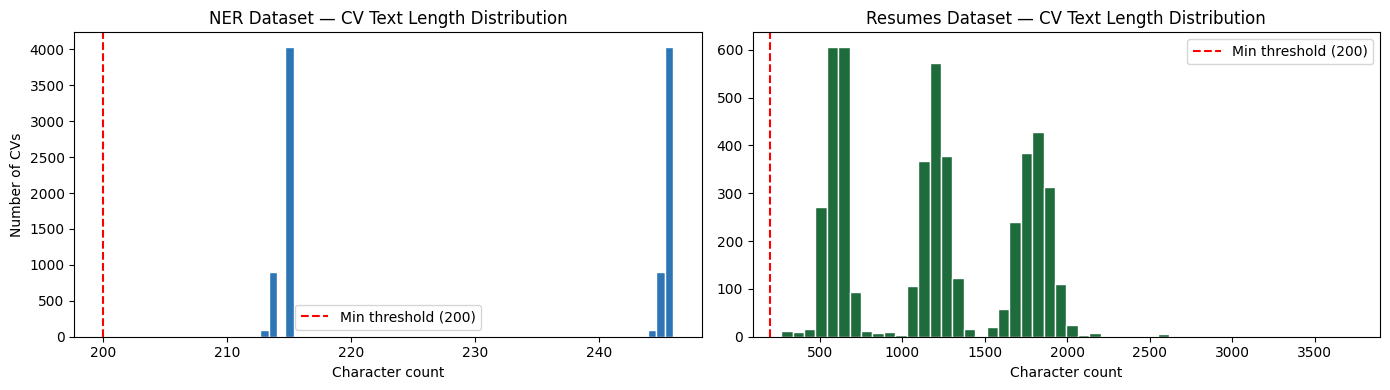

Chart saved to data/processed/


In [8]:
# Cell 8: Chart the text length distribution
# A histogram shows us the "shape" of our data.
# We want most CVs to be between 500–5000 characters.
# Outliers on either end are problems to fix in the cleaning step.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(ner_df['text_length'].clip(0, 8000), bins=50, color='#2E75B6', edgecolor='white')
axes[0].set_title('NER Dataset — CV Text Length Distribution', fontsize=12)
axes[0].set_xlabel('Character count')
axes[0].set_ylabel('Number of CVs')
axes[0].axvline(200, color='red', linestyle='--', label='Min threshold (200)')
axes[0].legend()

# Dataset 2 if it has a text column
res_text_col = find_text_column(resumes_df)
resumes_df['text_length'] = resumes_df[res_text_col].astype(str).str.len()
axes[1].hist(resumes_df['text_length'].clip(0, 8000), bins=50, color='#1E6B3C', edgecolor='white')
axes[1].set_title('Resumes Dataset — CV Text Length Distribution', fontsize=12)
axes[1].set_xlabel('Character count')
axes[1].axvline(200, color='red', linestyle='--', label='Min threshold (200)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/text_length_distribution.png', dpi=120)
plt.show()
print("Chart saved to data/processed/")

In [9]:
# Cell 9: Write a clean summary for our records
# This is what goes into our Week 1 report

summary = {
    'Dataset': ['Mehyaar NER Resumes', 'datasetmaster/resumes'],
    'Rows': [len(ner_df), len(resumes_df)],
    'Columns': [len(ner_df.columns), len(resumes_df.columns)],
    'Text Column': [ner_text_col, res_text_col],
    'Avg Text Length': [
        round(ner_df['text_length'].mean()),
        round(resumes_df['text_length'].mean())
    ],
    'Null Rows': [
        ner_df.isnull().any(axis=1).sum(),
        resumes_df.isnull().any(axis=1).sum()
    ]
}

summary_df = pd.DataFrame(summary)
summary_df

,Dataset,Rows,Columns,Text Column,Avg Text Length,Null Rows
0,Mehyaar NER Resumes,10064,2,pdf,230,0
1,datasetmaster/resumes,4817,12,experience,1201,4817


In [10]:
# Cell 10: Save raw DataFrames as CSV for Day 5 cleaning
# We save to data/raw/ — cleaned versions go to data/processed/ on Day 5

ner_df.to_csv('../data/raw/ner_resumes_raw.csv', index=False)
resumes_df.to_csv('../data/raw/datasetmaster_raw.csv', index=False)

print(f"Saved ner_resumes_raw.csv        ({len(ner_df)} rows)")
print(f"Saved datasetmaster_raw.csv      ({len(resumes_df)} rows)")
print()
print("Day 3 EDA complete.")
print("Tomorrow (Day 4) we download the remaining 3 datasets.")

Saved ner_resumes_raw.csv        (10064 rows)
Saved datasetmaster_raw.csv      (4817 rows)

Day 3 EDA complete.
Tomorrow (Day 4) we download the remaining 3 datasets.
